In [ ]:
#dzisiaj poćwicze jak działają wyszukiwarki chemiczne;
#przypomne wiedze jak komputer widzi molekułe;
#pierwszy prawdziwy smiliarity search engine.

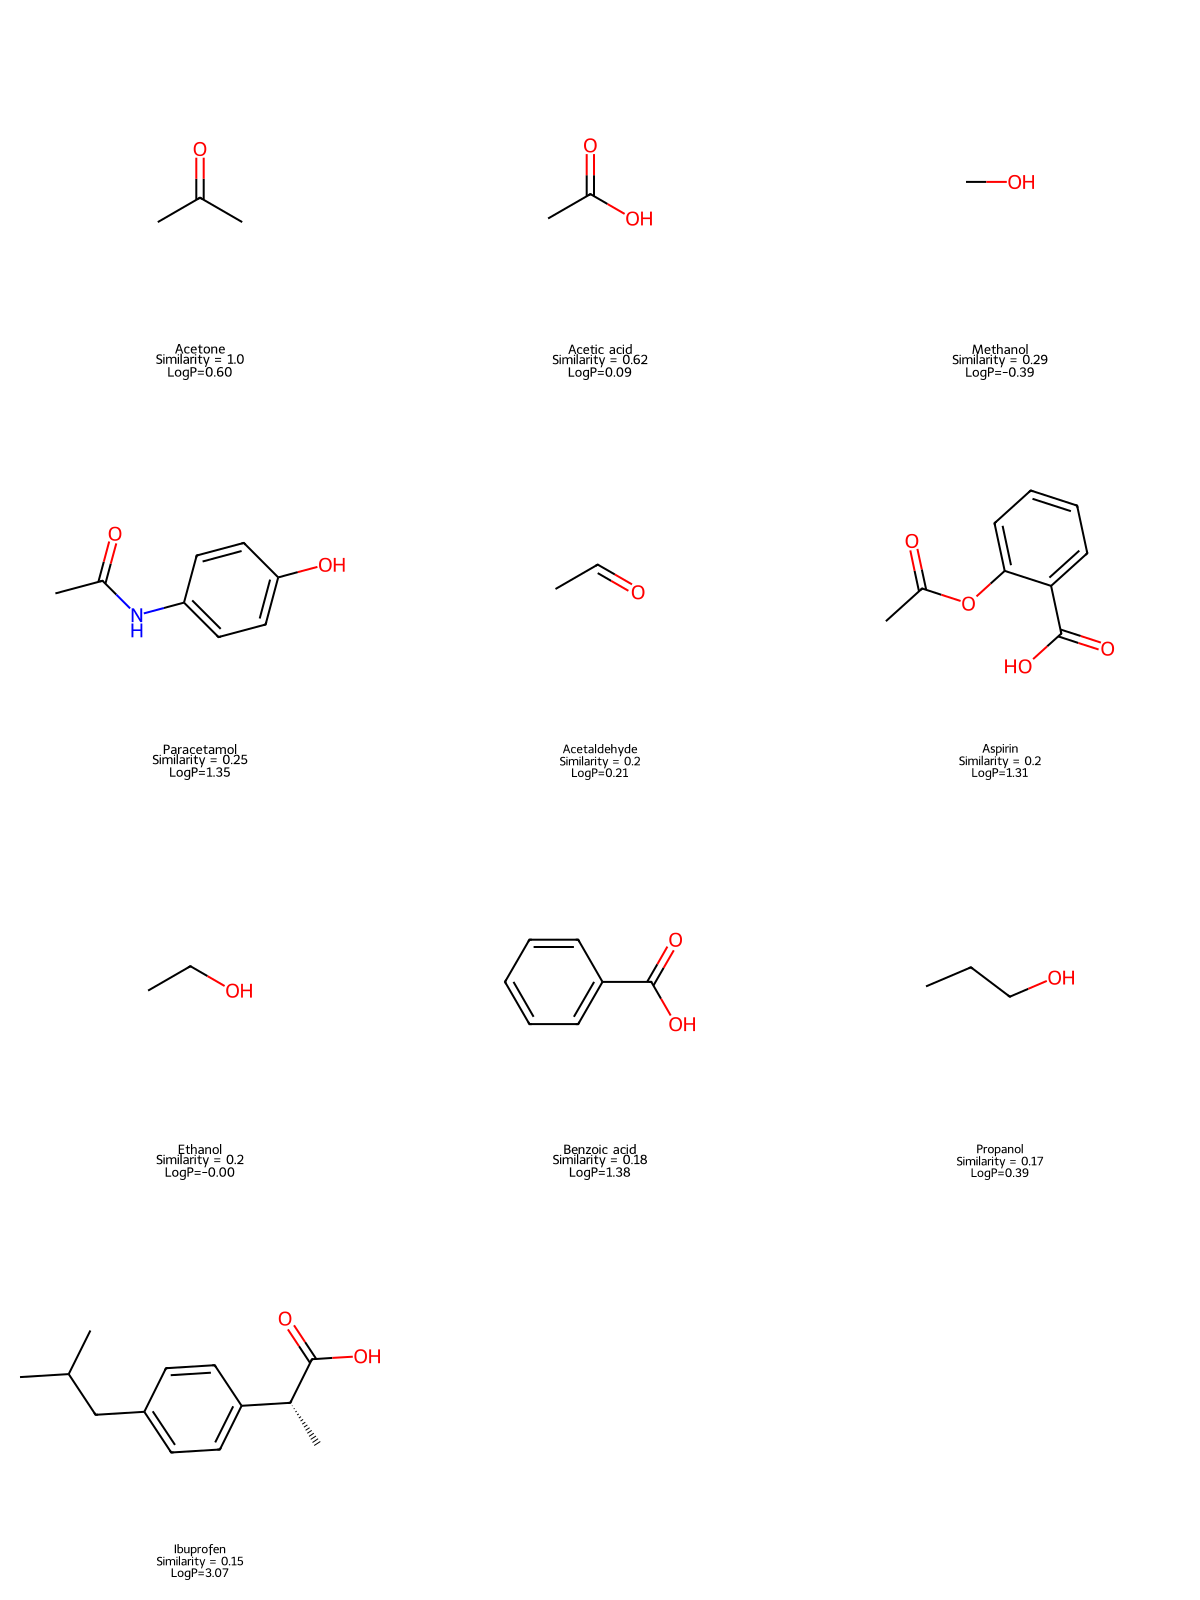

In [88]:
from rdkit import Chem
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem import Descriptors

IPythonConsole.ipython_useSVG = True #molekuly bedą rysowane jako grafika SVG;

import pandas as pd
from IPython.display import display

molecules = [ #mój mini-database;
    ("Methanol", "CO"),
    ("Ethanol", "CCO"),
    ("Propanol", "CCCO"),
    ("Butanol", "CCCCO"),

    ("Acetone", "CC(=O)C"),
    ("Acetaldehyde", "CC=O"),
    ("Benzaldehyde", "O=Cc1ccccc1"),

    ("Benzene", "c1ccccc1"),
    ("Phenol", "c1ccccc1O"),
    ("Aniline", "c1ccccc1N"),

    ("Acetic acid", "CC(=O)O"),
    ("Benzoic acid", "O=C(O)c1ccccc1"),

    ("Aspirin", "CC(=O)OC1=CC=CC=C1C(=O)O"),
    ("Paracetamol", "CC(=O)Nc1ccc(O)cc1"),
    ("Caffeine", "Cn1cnc2n(C)c(=O)n(C)c(=O)c12"),

    ("Nicotine", "CN1CCCC1c2cccnc2"),
    ("Ibuprofen", "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O")
]
morgan_gen = rdFingerprintGenerator.GetMorganGenerator( #generator Fingerprintów ;
    radius=2, #radius=lokalne środowisko atomów;
    fpSize=1024 #fpsize=liczba bitów; wielkość fingerprintu;
)
query_name= "Acetone" #molekula dla której szukamy podobnych związków;
for name, smiles in molecules:
    if name==query_name: #jesli nazwa to "query_name" wygeneruj obiekt;
        query_molecule=Chem.MolFromSmiles(smiles) #python przechodzi przez baze, jesli jest to nasze "query_name", generuje obietk molekuly;
        
query_fingerprint= morgan_gen.GetFingerprint(query_molecule) # generowanie cyfrowej reprezentacji dla molekuly; przeksztalcenie na bity;

results=[] #lista na wyniki

for name, smiles in molecules:#petla glowna;
    mol=Chem.MolFromSmiles(smiles) #wyciaga obiekty molekul z bazy i elementow "smiles";
    fp=morgan_gen.GetFingerprint(mol) #generuje fingerprinty z uzyskanych obiektow molekul "molecules";
    similarity = TanimotoSimilarity( #porownuje czasteczki i sprawdza ich podobienstwo w tym przypadku aspiryny z wszystkimi fingerprintami;
        query_fingerprint,
        fp
    )
    results.append([ #dodajemy do list nazwy, smiles oraz podobieństwo;
        name,
        smiles,
        round(similarity, 2)]
                  )
df = pd.DataFrame( #tworze tabele wynikow;
    results, #dodaje liste results;
    columns=["Names", "SMILES", "Similarity",] #dodaje kolumny;
                )
df = df.sort_values("Similarity", #dodaje sortowanie do tabeli;
                    ascending=False
                   )
top10=df.head(10) #zostaje tylko 10 najbardziej podobnych związków;

mols=[] #obrazy molekuł;
legends=[] #legendy obrazków

for _, row in top10.iterrows(): 
    mol=Chem.MolFromSmiles(row["SMILES"]) #Każdy wiersz tabeli analizowany jest po kolei.
    
    mols.append(mol) #dodanie molekuł do listy mols;
    logp=Descriptors.MolLogP(mol)
    legends.append(
        f'{row["Names"]}\nSimilarity = {row["Similarity"]}\n'f'LogP={logp:.2f}'
    )

img=MolsToGridImage(
mols,
molsPerRow=3,
subImgSize=(400,400),
legends=legends
        )
display(img)